IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [2]:
df = pd.read_csv(
    "../data/raw/reliance.csv",
    index_col=0,
    parse_dates=True
)

df.head()

C:\Users\HP\AppData\Local\Temp\ipykernel_16508\2773123656.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df = pd.read_csv(


,Close,High,Low,Open,Volume
Price,,,,,
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,NaN,NaN,NaN,NaN,NaN
2020-01-01,675.3241577148438,683.1528519736394,673.4900624593615,679.0819357370663,14004468
2020-01-02,686.8212280273438,689.3487905881979,676.397899264457,676.397899264457,17710316
2020-01-03,687.6488037109375,689.6618949086101,681.3187290426969,685.7922517653002,20984698


In [3]:
df['Close'] = pd.to_numeric(df['Close'], errors='coerce')

CALCULATE SMA

In [4]:
df['SMA_20'] = df['Close'].rolling(window=20).mean()

df['SMA_50'] = df['Close'].rolling(window=50).mean()

VISUALIZE SMA

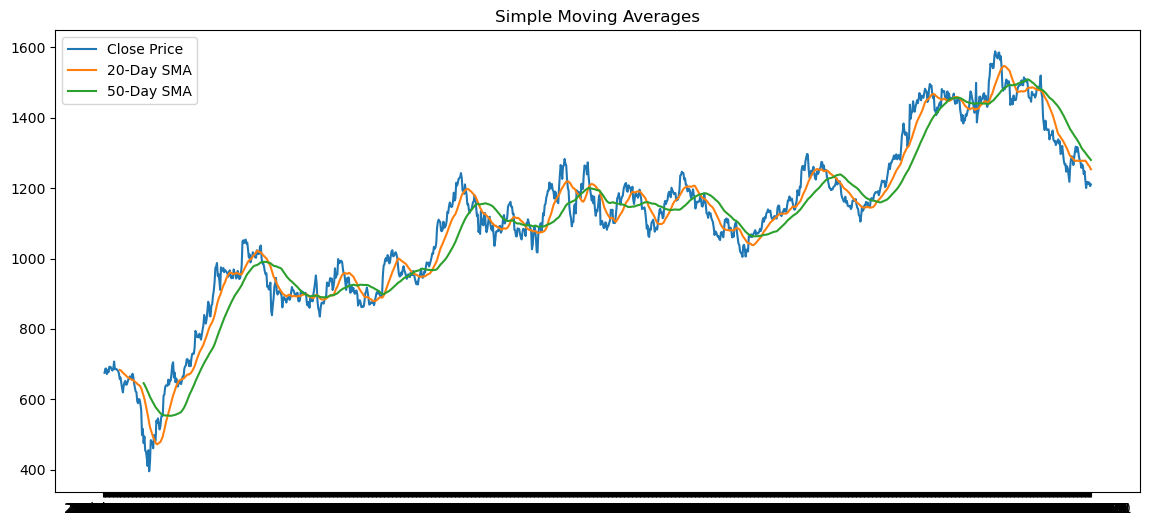

In [5]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close Price')

plt.plot(df['SMA_20'], label='20-Day SMA')

plt.plot(df['SMA_50'], label='50-Day SMA')

plt.legend()

plt.title("Simple Moving Averages")

plt.show()

CALCULATE EMA

In [6]:
df['EMA_20'] = df['Close'].ewm(span=20, adjust=False).mean()

PLOT EMA

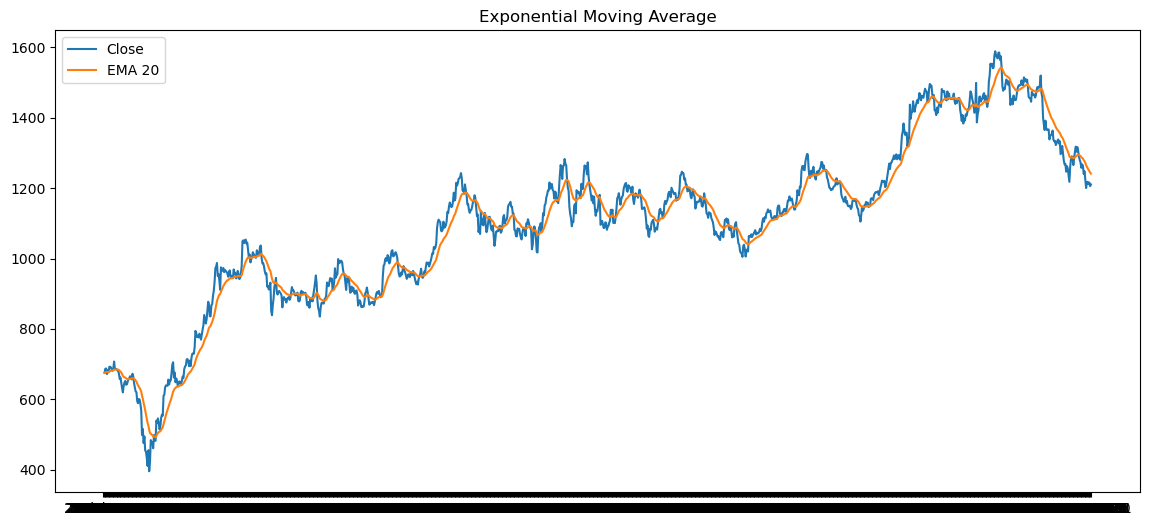

In [7]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['EMA_20'], label='EMA 20')

plt.legend()

plt.title("Exponential Moving Average")

plt.show()

CALCULATE RSI

In [9]:
delta = df['Close'].diff()

gain = delta.where(delta > 0, 0)

loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(window=14).mean()

avg_loss = loss.rolling(window=14).mean()

rs = avg_gain / avg_loss

df['RSI'] = 100 - (100 / (1 + rs))

PLOT RSI

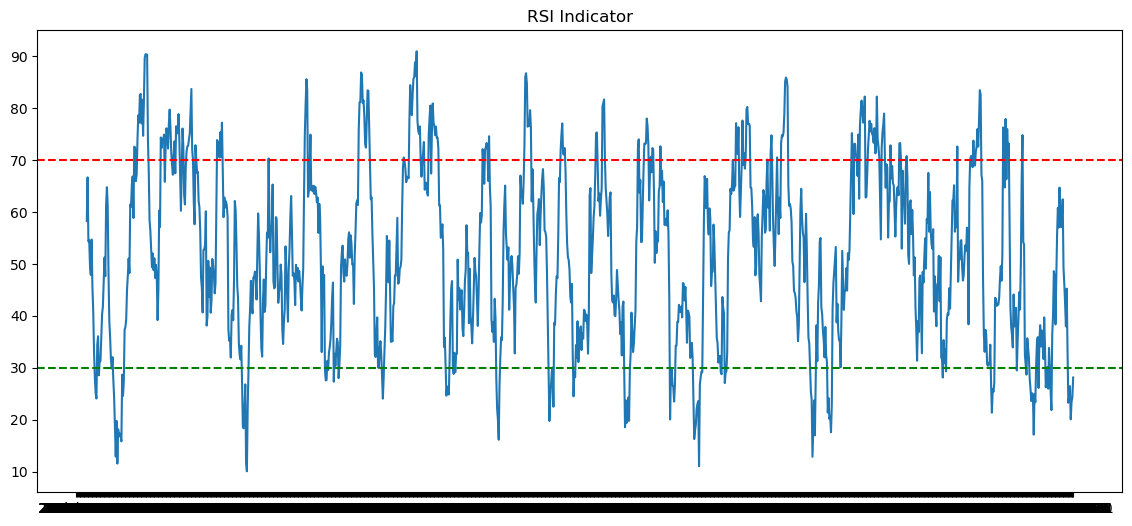

In [10]:
plt.figure(figsize=(14,6))

plt.plot(df['RSI'])

plt.axhline(70, color='red', linestyle='--')

plt.axhline(30, color='green', linestyle='--')

plt.title("RSI Indicator")

plt.show()

CALCULATE MACD

In [11]:
ema12 = df['Close'].ewm(span=12, adjust=False).mean()

ema26 = df['Close'].ewm(span=26, adjust=False).mean()

df['MACD'] = ema12 - ema26

df['Signal_Line'] = df['MACD'].ewm(span=9, adjust=False).mean()

PLOT MACD

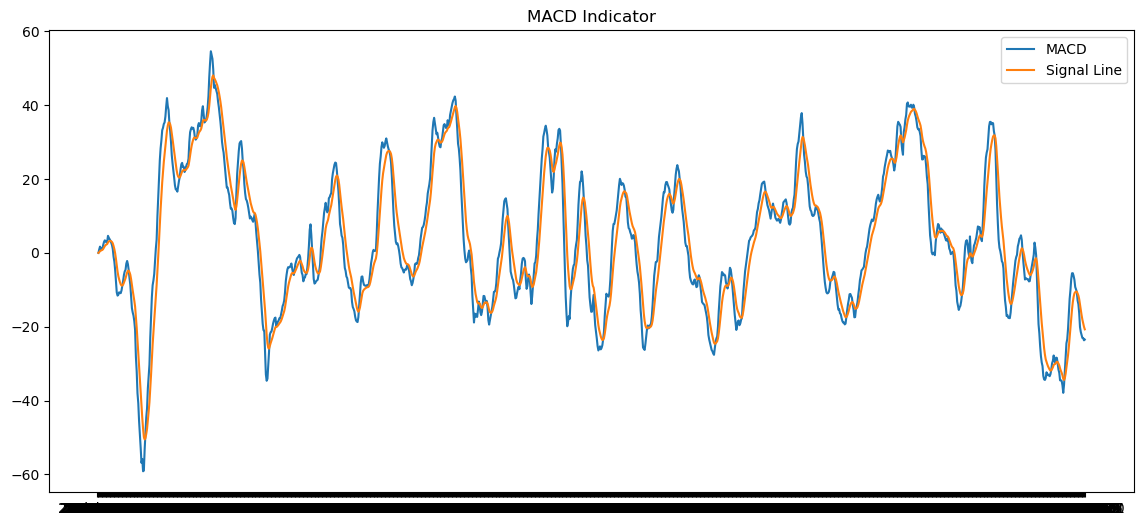

In [12]:
plt.figure(figsize=(14,6))

plt.plot(df['MACD'], label='MACD')

plt.plot(df['Signal_Line'], label='Signal Line')

plt.legend()

plt.title("MACD Indicator")

plt.show()

CALCULATE BOLLINGER BANDS

In [13]:
df['Middle_Band'] = df['Close'].rolling(window=20).mean()

std_dev = df['Close'].rolling(window=20).std()

df['Upper_Band'] = df['Middle_Band'] + (2 * std_dev)

df['Lower_Band'] = df['Middle_Band'] - (2 * std_dev)

PLOT BOLLINGER BANDS

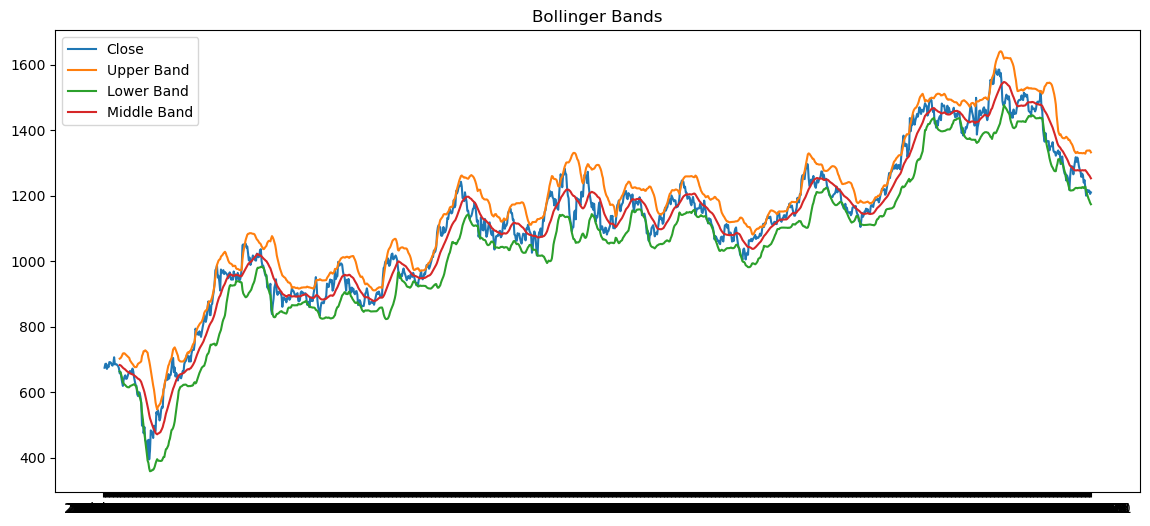

In [14]:
plt.figure(figsize=(14,6))

plt.plot(df['Close'], label='Close')

plt.plot(df['Upper_Band'], label='Upper Band')

plt.plot(df['Lower_Band'], label='Lower Band')

plt.plot(df['Middle_Band'], label='Middle Band')

plt.legend()

plt.title("Bollinger Bands")

plt.show()

In [15]:
df.to_csv("../data/processed/reliance_with_indicators.csv")